# Fase 1: Análisis de Distribución de Clases

En esta etapa se decide qué clases se conservan basándose en su representatividad y relevancia estadística.

* **Conteo de Instancias por Categoría:**
    * **Objetivo:** Identificar clases "minoritarias" que el modelo no aprenderá bien.
    * **Visualización:** Gráfico de barras horizontal ordenado por frecuencia.
    * **Decisión:** Evaluar si clases con < 50-100 instancias requieren *Data Augmentation* o eliminación.
* **Imágenes por Categoría vs. Objetos por Categoría:**
    * **Objetivo:** Determinar si una clase está bien distribuida en el dataset o si aparece concentrada en pocas imágenes (ej. 50 sillas en una sola foto). Esto influye en la división de *Train/Val/Test*.
* **Matriz de Co-ocurrencia:**
    * **Objetivo:** Analizar qué objetos aparecen juntos para entender el contexto (ej. la relación entre "Mesa" y "Silla").

In [2]:
# Librerías
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Rutas base
base_dir = "/Users/admin/Documents/TFM_UNIR/01_ING_DATOS"
train_annot_path = os.path.join(base_dir, "Dataset", "train", "_annotations.coco.json")

In [3]:
# Cargar datos
try:
    coco = COCO(train_annot_path)
    print("✅ Archivo de anotaciones cargado correctamente.")
except Exception as e:
    print(f"❌ Error al cargar el archivo: {e}")
    print("Verificar que la ruta 'train_annot_path' sea correcta.")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Archivo de anotaciones cargado correctamente.


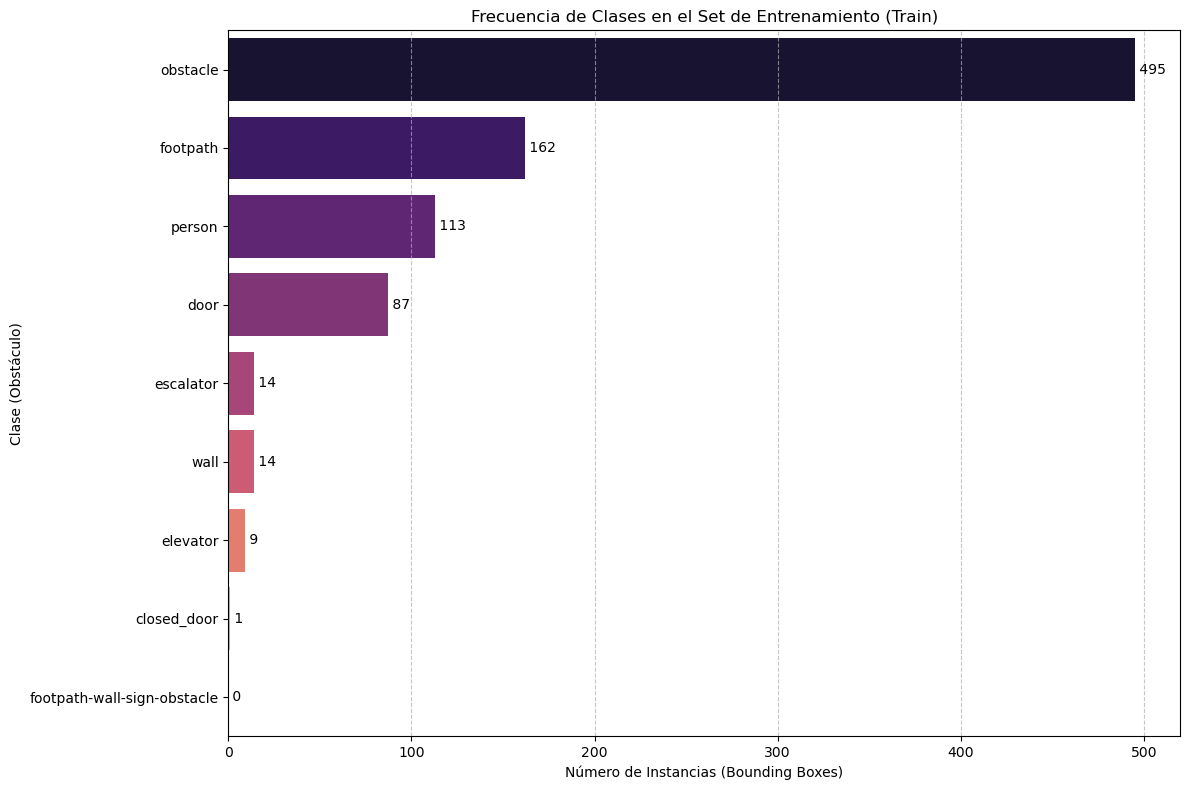


--- Tabla de Distribución ---
| Category                    |   Count |
|:----------------------------|--------:|
| obstacle                    |     495 |
| footpath                    |     162 |
| person                      |     113 |
| door                        |      87 |
| escalator                   |      14 |
| wall                        |      14 |
| elevator                    |       9 |
| closed_door                 |       1 |
| footpath-wall-sign-obstacle |       0 |


In [4]:
# OBTENER CATEGORÍAS Y CONTEOS
# 1. Obtener IDs de categorías y sus nombres
cats = coco.loadCats(coco.getCatIds())
cat_names = [cat['name'] for cat in cats]
cat_ids = [cat['id'] for cat in cats]

# 2. Contar anotaciones por categoría
cat_counts = []
for cat_id in cat_ids:
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    count = len(ann_ids)
    cat_counts.append(count)

# 3. Crear DataFrame para facilitar el manejo
df_counts = pd.DataFrame({
    'Category': cat_names,
    'Count': cat_counts,
    'Category_ID': cat_ids
}).sort_values('Count', ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_counts, y='Category', x='Count', palette='magma', hue='Category', legend=False)
plt.title('Frecuencia de Clases en el Set de Entrenamiento (Train)')
plt.xlabel('Número de Instancias (Bounding Boxes)')
plt.ylabel('Clase (Obstáculo)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir valores al lado de cada barra
for i, v in enumerate(df_counts['Count']):
    ax.text(v, i, f' {v}', va='center', fontsize=10)

scale_type = 'linear'  # Cambiar a 'log' para escala logarítmica
# Aplicar escala según opción
if scale_type == 'log':
    plt.xscale('log')
    plt.xlabel('Número de Instancias (Bounding Boxes) - Escala Logarítmica')

plt.tight_layout()
plt.show()

# --- IMPRIMIR TABLA RESUMEN ---
print("\n--- Tabla de Distribución ---")
print(df_counts[['Category', 'Count']].to_markdown(index=False))

**Análisis:**

En total el dataset tiene 9 clases.

1. Las cuatro clases con más datos son: obstacle (495), footpath (162), person (113) y door (87). 

2. Las demás clases: escalator, wall, elevator, closed_door, tienen menos de 20 instancias. La clase footpath-wall-sign-obstacle no tiene ninguna instancia. 

2. Las clases que realmente podrían ser útiles para un sistema de navegación de un robot móvil son: obstacle, footpath, person y door.

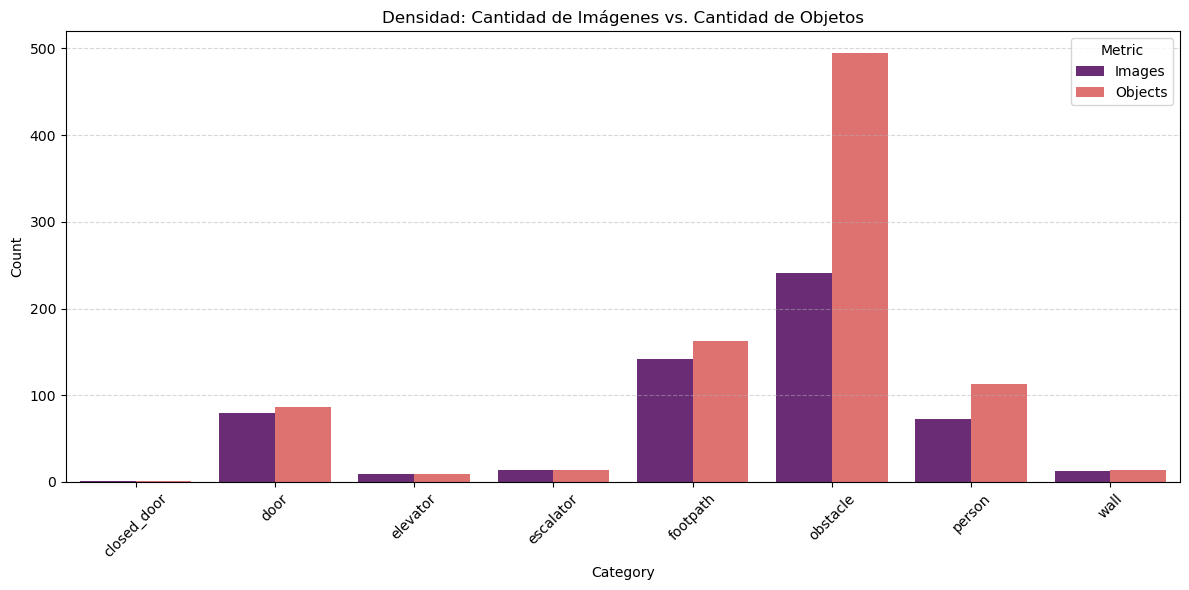

In [4]:
import numpy as np

# --- IMÁGENES VS OBJETOS ---
# Objetivo: Ver si los objetos están bien distribuidos o amontonados
img_counts = []
obj_counts = []
cat_labels = []

# Filtramos solo las clases que tienen anotaciones para limpiar el gráfico
active_cat_ids = []

for cat_id in cat_ids:
    # Obtener IDs de imágenes que contienen esta categoría
    img_ids = coco.getImgIds(catIds=[cat_id])
    n_imgs = len(img_ids)
    
    # Obtener IDs de anotaciones (objetos)
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    n_objs = len(ann_ids)
    
    if n_objs > 0: # Solo guardamos si hay datos
        cat_info = coco.loadCats([cat_id])[0]
        cat_labels.append(cat_info['name'])
        img_counts.append(n_imgs)
        obj_counts.append(n_objs)
        active_cat_ids.append(cat_id)

# Crear DataFrame para graficar
df_density = pd.DataFrame({
    'Category': cat_labels,
    'Images': img_counts,
    'Objects': obj_counts
})

# Graficar
df_melted = df_density.melt(id_vars='Category', var_name='Metric', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Category', y='Count', hue='Metric', palette='magma')
plt.title('Densidad: Cantidad de Imágenes vs. Cantidad de Objetos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

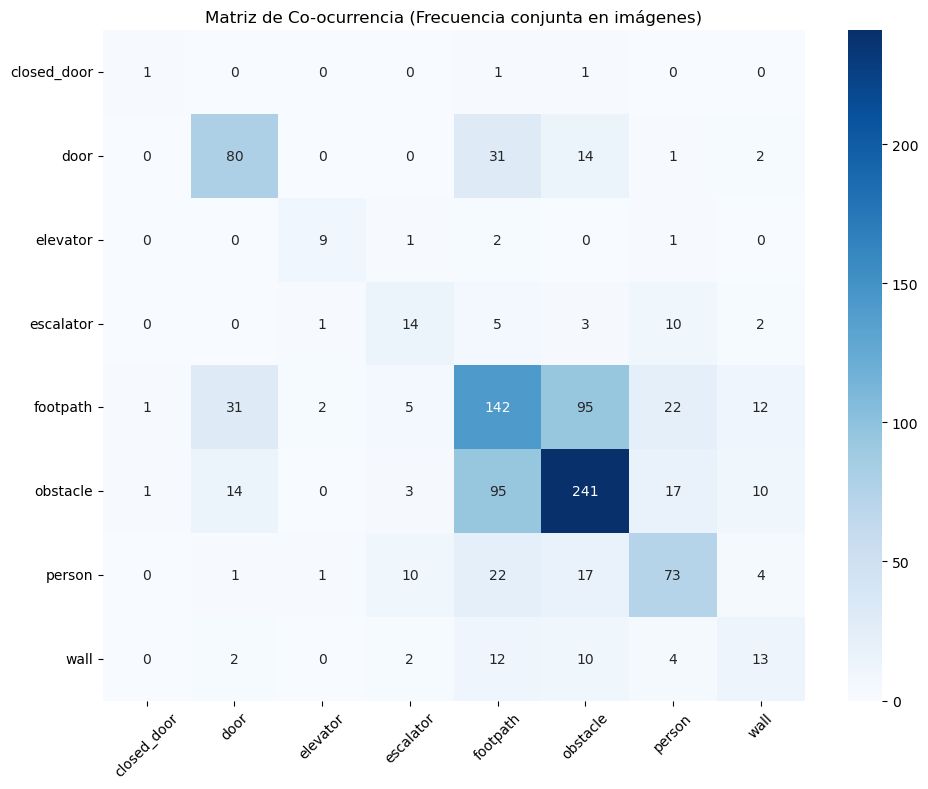

In [5]:
# --- MATRIZ DE CO-OCURRENCIA ---
# Objetivo: Ver qué clases aparecen juntas
# Mapeamos ID de categoría a índice de matriz (0 a N-1)
id_to_idx = {cat_id: i for i, cat_id in enumerate(active_cat_ids)}
num_classes = len(active_cat_ids)
co_occurrence_matrix = np.zeros((num_classes, num_classes))

# Obtener todas las imágenes que tienen al menos una anotación
all_img_ids = coco.getImgIds()

for img_id in all_img_ids:
    # Cargar anotaciones de esa imagen
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    
    # Extraer categorías únicas presentes en esta imagen
    present_cat_ids = set([ann['category_id'] for ann in anns if ann['category_id'] in id_to_idx])
    
    # Llenar la matriz (si clase A y B están en la imagen, sumamos 1 a la intersección)
    for id1 in present_cat_ids:
        for id2 in present_cat_ids:
            idx1 = id_to_idx[id1]
            idx2 = id_to_idx[id2]
            co_occurrence_matrix[idx1, idx2] += 1

# Graficar Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=cat_labels, yticklabels=cat_labels)
plt.title('Matriz de Co-ocurrencia (Frecuencia conjunta en imágenes)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Calcular ratio Objetos/Imagen 
print("\n--- Ratio de Densidad (Promedio de objetos por imagen donde aparece la clase) ---")
df_density['Ratio'] = df_density['Objects'] / df_density['Images']
print(df_density[['Category', 'Ratio']].sort_values('Ratio', ascending=False).to_markdown(index=False))


--- Ratio de Densidad (Promedio de objetos por imagen donde aparece la clase) ---
| Category    |   Ratio |
|:------------|--------:|
| obstacle    | 2.05394 |
| person      | 1.54795 |
| footpath    | 1.14085 |
| door        | 1.0875  |
| wall        | 1.07692 |
| closed_door | 1       |
| elevator    | 1       |
| escalator   | 1       |


**Análisis del gráfico de Densidad:**

1. En la clase `obstacle` hay más objetos que imágenes. Es decir, una alta densidad promedio de 2.05. Esto nos da un posible cluster en la clase `obstacle`. Los obstáculos no aparecen aislados. Es común tener 2, 3 o más obstáculos en una misma foto. Si los objetos están muy juntos, el modelo podría tener dificultad de separarlos y detectar un solo gran obstáculo. Esto será importante en el algoritmo de **Non-Maximum Suppresion (NMS)** a implementar.

2. En `person` pasa algo similar, aunque menos extremo con densidad promedio de 1.54. Esto indica que las personas tienden a aparecer en pequeños grupos o pares, raramente solas en el dataset.

3. Hay una cierta estabilidad de las clases `door` y `footpath` en cuanto a densidad, pues tienen 1.14 y 1.08 respectivamente. Esto indica que normalmente hay un solo camino dominante y una o dos puertas visibles.

**Análisis de la Matriz de Co-Ocurrencia**

1. La interacción más importante está entre `footpath` y `obstacle`, con 95 co-ocurrencias. Esto sugiere que casi el 40% de las veces que hay un obstáculo, hay un camino identificado. Esto es bueno para navegación pues el modelo aprenderá a buscar obstáculos dentro del contexto de un camino.

2. La independencia de `person` , es decir, que tiene baja co-ocurrencia con `door` y con `footpath` sugiere que las personas aparecen en contextos variados, no solo transitando. Esto podría obligar al detector a aprender las características de "persona" por sí mismas, sin depender tanto del fondo (puertas/caminos), lo cual es positivo a nivel de robustez.

3. Las clases `obstacle`, `footpath`, `person` y `door` son las únicas con volumen y relaciones suficientes para entrenar algo útil. Las demás clases tienen tan pocos ejemplos y co-ocurrencias que es improbable que el modelo aprenda a detectarlas de manera efectiva.

# Fase 2: Análisis Geométrico de Bounding Boxes

Los modelos como YOLO dependen drásticamente de la geometría de las cajas delimitadoras.

* **Distribución de Tamaños (Área):**
    * **Objetivo:** Clasificar objetos en **Pequeños**, **Medianos** y **Grandes** (Estándar COCO).
    * **Impacto:** Clases predominantemente pequeñas requieren arquitecturas de mayor resolución.
* **Relación de Aspecto (Aspect Ratio):**
    * **Objetivo:** Graficar ancho vs. alto.
    * **Impacto:** Esencial para definir los *Anchors*. Ayuda a identificar si los obstáculos son verticales (personas) u horizontales (sofás).
* **Posición Espacial (Heatmap):**
    * **Objetivo:** Mapa de calor de los centros de las cajas.
    * **Alerta:** Prevenir el **sesgo central**, asegurando que el modelo detecte objetos en las esquinas.

In [8]:
import numpy as np
import matplotlib.patches as patches

# FILTRADO Y EXTRACCIÓN DE CLASES PREDOMINANTES
target_classes = ['obstacle', 'footpath', 'person', 'door']
# Obtener IDs solo de las clases objetivo
target_cat_ids = coco.getCatIds(catNms=target_classes)
# Mapeo de ID a Nombre para gráficas
id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(target_cat_ids)}

# Listas para almacenar datos
areas = []
ratios = []
centers_x = []
centers_y = []
categories = []
sizes_coco = [] # Small, Medium, Large

# Iterar sobre cada categoría filtrada
for cat_id in target_cat_ids:
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    anns = coco.loadAnns(ann_ids)
    
    for ann in anns:
        # Bounding Box: [x, y, width, height]
        x, y, w, h = ann['bbox']
        
        # Ignorar cajas corruptas (w o h <= 0)
        if w <= 0 or h <= 0: continue
            
        # 1. Área y Clasificación COCO
        area = w * h
        if area < 32**2:
            size_label = 'Small (<32²)'
        elif area < 96**2:
            size_label = 'Medium'
        else:
            size_label = 'Large (>96²)'
            
        # 2. Aspect Ratio (Ancho / Alto)
        # Ratio > 1 = Horizontal, Ratio < 1 = Vertical
        ratio = w / h
        
        # 3. Posición Normalizada (Centro)
        img_info = coco.loadImgs(ann['image_id'])[0]
        img_w, img_h = img_info['width'], img_info['height']
        
        # Centro normalizado (0 a 1)
        cx = (x + w/2) / img_w
        cy = (y + h/2) / img_h
        
        # Guardar datos
        areas.append(area)
        ratios.append(ratio)
        centers_x.append(cx)
        centers_y.append(cy)
        categories.append(id_to_name[cat_id])
        sizes_coco.append(size_label)

# Crear DataFrame
df_geo = pd.DataFrame({
    'Category': categories,
    'Area': areas,
    'Ratio': ratios,
    'Size_COCO': sizes_coco,
    'Center_X': centers_x,
    'Center_Y': centers_y
})

<Figure size 1000x600 with 0 Axes>

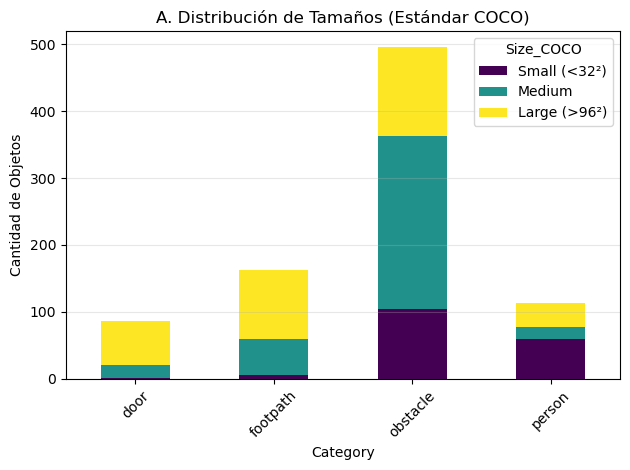


--- Porcentaje de Tamaños por Clase ---
| Category   |   Small (<32²) |   Medium |   Large (>96²) |
|:-----------|---------------:|---------:|---------------:|
| door       |           1.15 |    22.99 |          75.86 |
| footpath   |           3.7  |    32.72 |          63.58 |
| obstacle   |          21.01 |    52.12 |          26.87 |
| person     |          53.1  |    15.04 |          31.86 |


In [17]:
# --- VISUALIZACIÓN A: Distribución de Tamaños COCO ---
plt.figure(figsize=(10, 6))
size_counts.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('A. Distribución de Tamaños (Estándar COCO)')
plt.xlabel('Category')
plt.ylabel('Cantidad de Objetos')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.legend(title='Size_COCO')
plt.tight_layout()
plt.show()

print("\n--- Porcentaje de Tamaños por Clase ---")
size_pct = size_counts.div(size_counts.sum(axis=1), axis=0) * 100
print(size_pct.round(2).to_markdown())

/var/folders/04/3m9yp1sj1fl1k_jfy0yrwhmh0000gn/T/ipykernel_47213/3092279164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_geo, x='Category', y='Ratio', palette='Set2')


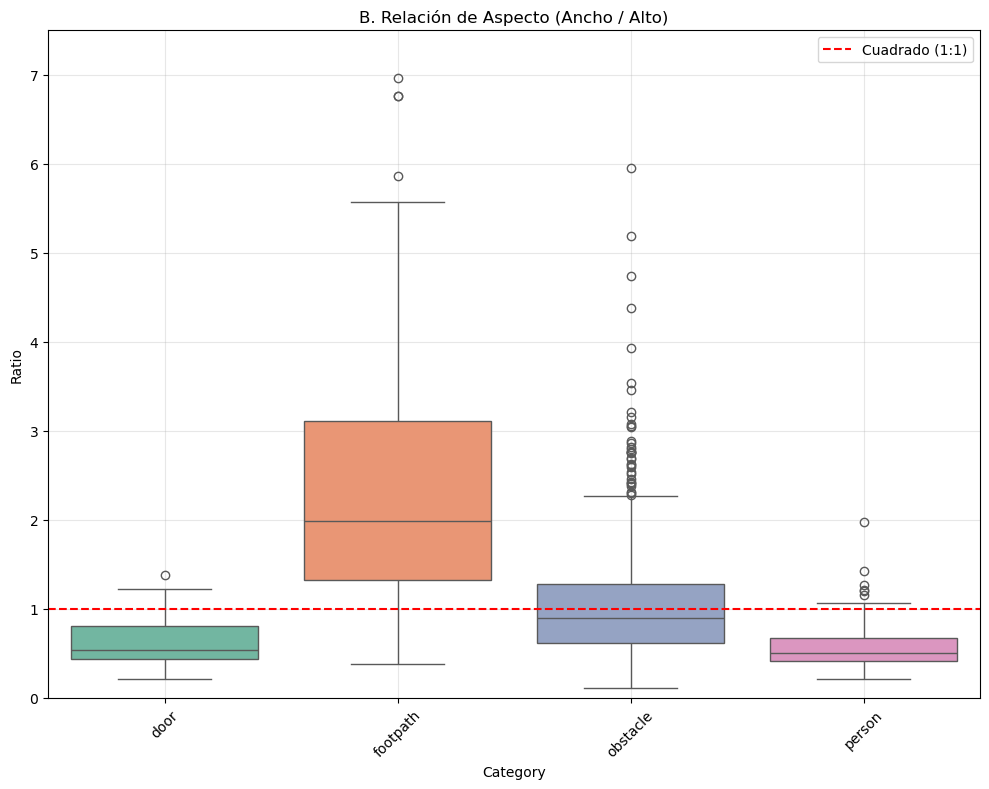

In [21]:
# --- VISUALIZACIÓN B: Aspect Ratio ---
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_geo, x='Category', y='Ratio', palette='Set2')
plt.title('B. Relación de Aspecto (Ancho / Alto)')
plt.axhline(1, color='r', linestyle='--', label='Cuadrado (1:1)')
plt.ylim(0, 7.5)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

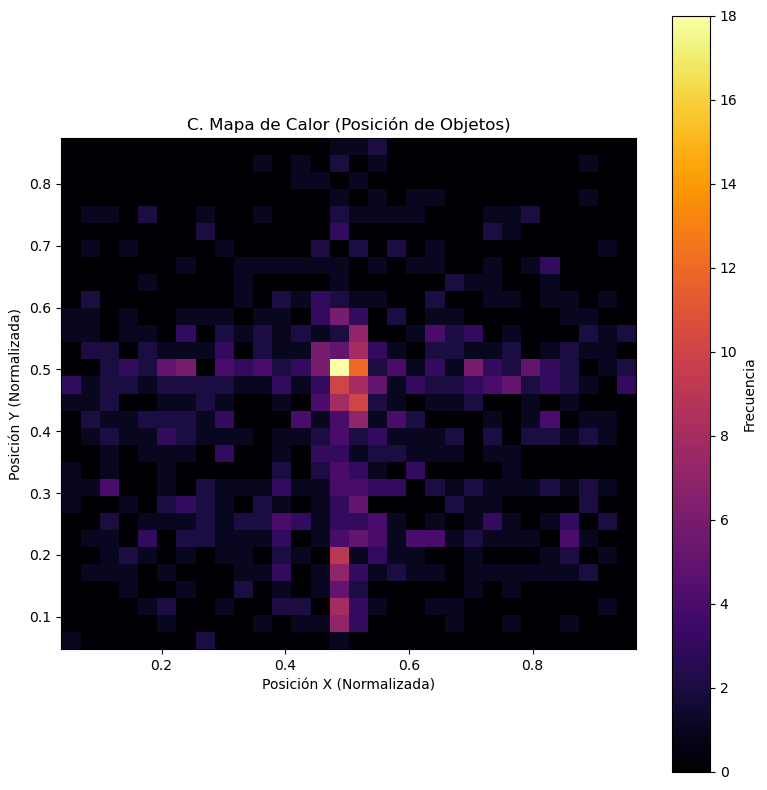

In [15]:
# --- VISUALIZACIÓN C: Heatmap Espacial ---
plt.figure(figsize=(8, 8))
h = plt.hist2d(df_geo['Center_X'], 1 - df_geo['Center_Y'], bins=30, cmap='inferno')
plt.title('C. Mapa de Calor (Posición de Objetos)')
plt.xlabel('Posición X (Normalizada)')
plt.ylabel('Posición Y (Normalizada)')
plt.gca().set_aspect('equal')
plt.colorbar(h[3], label='Frecuencia')
plt.tight_layout()
plt.show()

**Análisis de la Distribución de Tamaños de los Boxes:**

1. En la clase `person` el 53% de los boxes son pequeños (menores a 32x32 píxeles). Esto podría ser riesgosos o alarmante pues más de la mitad de las personas son "small" y eso implica que:
- las personas están mayormente al final de los pasillos largos o lejos de la cámara.
- los modelos como YOLO reducen la imagen varias veces (downsampling), por lo que un objeto de 32x32 pixeles podría quedar representado en solo 1 o 2 pixeles del mapa de características final, dificultando su detección.
- probablemente se necesiten técnicas como el *tiling* (recortar la imagen en parches) para que el robot no "atropelle" (según la lógica de control) a personas que están lejanas (asumiendo que trabaja a baja tasa de frames). Aunque este no es el alcance del proyecto actual, es un punto a considerar para futuras mejoras.

2. En la clase `obstacle` se tiene el 21% de boxes pequeños, que podría ser significativo para un robot de interiores. Probablemente se trate de obstáculos como cables, zapatos, basura, patas de sillas, etc. Son los obstáculos más difíciles de ver pero los que más fácil pueden atascar las ruedas de un robot. Si el modelo falla aquí, el robot se atasca. Por lo tanto, es crucial que el modelo tenga buena precisión en la detección de estos pequeños obstáculos.

3. En las clases `door` y `footpath`, hay una estabilidad relativa a tener boxes medianos y grantes, por lo que serán clases muy fáciles de aprender para el modelo, pues tienen muchos pixeles de información.


**Análisis de la relación de aspecto (ancho/alto) de los Boxes:**

1. las clases `person` y `door` tienen cajas verticales y consistentes, el modelo probablemente aprenda muy rápido a detectar estas clases:
- Al estar completamente por debajo del Ratio=1, confirman que son objetos verticales.
- Al tener cajas cortaas hay poca varianza, sus formas son muy predecibles.

2. la clase `footpath` tienen cajas horizontales, al estar por encima del Ratio=1. Tiene sentido porque el camino o el suelo suele abaracar el ancho de la imagen. 

3. la clase `obstacle` tiene cajas diversas, tanto horizontales como verticales debido a:
- La caja es más grande y cruza el Ratio=1.
- Significa que un obstáculo puede ser un palo de escoba (ratio 0.3) o un sofá (ratio 3.0).
- Los modelos usan "anchors" (cajas predefinidas) para buscar objetos. Si se define "anchors" solo cuadrados o verticales, el modelo fallará al detectar objetos anchos.
- Se necesitará asegurar que la configuración de "anchors" incluya cajas de todas las proporciones (altas, cuadradas y anchas) para cubrir esa varianza.

**Análisis del mapa de calor de la ubicación de los boxes:**

1. Existe una "mancha" central de alta frecuencia de boxes en la parte central. Esto indica que los modelos podrán ser más precisos detectando justo lo que se tiene enfrente (en la imagen) de la cámara. Es probable que se tenga un riesgo ya a nivel práctico en la implementación de un robot en tanto que si el robot está girando y un obstáculo entra por una esquina de la visión, el modelo podría no detectarlo hasta que esté casi en el centro, reduciendo el tiempo de reaccion para frenar o hacer cualquier otra acción programada. Sin embargo, esta limitación no es exclusiva de este dataset, sino que es común en muchos datasets de visión por computador y no está cubierto en el alcance del proyecto actual.

2. Existe una "mancha" en la parte inferior central, que podría ser la predominancia de la clase `footpath`. Esto es positivo, pues indica que el modelo aprenderá a identificar el camino justo en la parte baja de la imagen, que es donde se espera que esté el suelo. Esto indica también que el dataset tiene muchos ejemplos de "suelo" visible y obstáculos cercanos a ese suelo, lo cual es positivo para la navegación del robot.

3. La parte superior del mapa de calor está prácticamente "vacío" o sin "manchas" de alta frecuencia. Es relativamente lógico dado que para las 4 clases filtradas, no esperamos ver obstáculos en la parte alta de la imagen (techo, cielo, etc). Esto indica que el dataset está bien construido y enfocado en las áreas relevantes de interiores.

Posibles mejoras al dataset:
1. Relacionadas al tamaño de los boxes de `person`: usar arquitecturas con "detectores de pequeñas escalas". No es viable aumentar la resolución porque queremos mantener eficiencia en tiempo real y bajo uso de memoria.

2. Relacionados a la forma de los boxes de `obstacle`: implementar diferentes "anchors" para cubrir la variedad de formas (altas, cuadradas y anchas).

3. Relacionados con la ubicación de los boxes a nivel general: usar Mosaic Data Augmentation para forzar al modelo a aprender a detectar objetos en las esquinas y bordes de la imagen, no solo en el centro.

# Fase 3: Complejidad de la Escena

Determina la carga computacional y la dificultad técnica del entrenamiento.

* **Objetos por Imagen (Densidad):**
    * **Objetivo:** Histograma de cantidad de objetos por foto.
    * **Impacto:** Imágenes vacías ayudan a reducir falsos positivos; imágenes muy densas requieren más memoria GPU.
* **Superposición (Occlusión):**
    * **Objetivo:** Calcular el **IoU (Intersection over Union)** entre cajas.
    * **Impacto:** Si hay mucha superposición, se requiere un ajuste fino del *Non-Maximum Suppression (NMS)*.

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
target_classes = ['obstacle', 'footpath', 'person', 'door']
target_cat_ids = coco.getCatIds(catNms=target_classes)

Procesando imágenes para calcular IoU y Densidad...


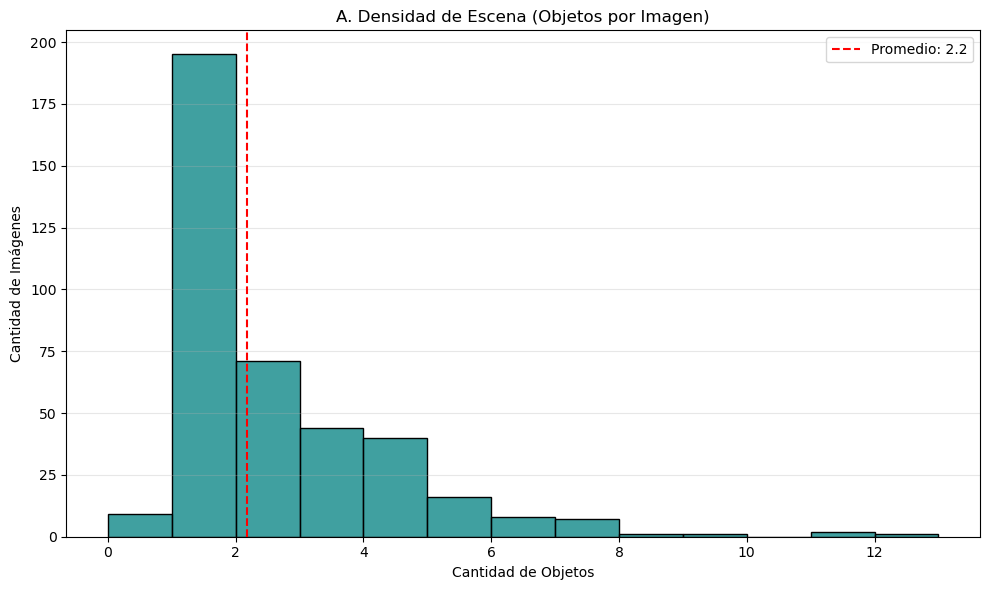

In [24]:
# --- DENSIDAD (Objetos por Imagen) ---
img_ids = coco.getImgIds()
density_counts = []
ious = []  # Lista para guardar el IoU máximo de cada objeto

print("Procesando imágenes para calcular IoU y Densidad...")

for img_id in img_ids:
    # Cargar anotaciones de la imagen filtradas por nuestras clases
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=target_cat_ids)
    anns = coco.loadAnns(ann_ids)
    
    # A. Conteo de densidad
    count = len(anns)
    density_counts.append(count)
    
    # B. Cálculo de IoU (Solo si hay más de 1 objeto)
    if count > 1:
        boxes = [ann['bbox'] for ann in anns]
        # Convertir a formato [x1, y1, x2, y2] para facilitar cálculo
        # bbox original es [x, y, w, h]
        boxes_xyxy = []
        for b in boxes:
            boxes_xyxy.append([b[0], b[1], b[0]+b[2], b[1]+b[3]])
        
        boxes_np = np.array(boxes_xyxy)
        
        # Calcular IoU de todos contra todos en esta imagen
        # Área de cada caja
        areas = (boxes_np[:, 2] - boxes_np[:, 0]) * (boxes_np[:, 3] - boxes_np[:, 1])
        
        for i in range(count):
            boxA = boxes_np[i]
            max_iou_for_this_box = 0
            
            for j in range(count):
                if i == j: continue # No comparar consigo mismo
                
                boxB = boxes_np[j]
                
                # Coordenadas de la intersección
                xA = max(boxA[0], boxB[0])
                yA = max(boxA[1], boxB[1])
                xB = min(boxA[2], boxB[2])
                yB = min(boxA[3], boxB[3])
                
                # Área de intersección
                interWidth = max(0, xB - xA)
                interHeight = max(0, yB - yA)
                interArea = interWidth * interHeight
                
                # Área de unión
                unionArea = areas[i] + areas[j] - interArea
                
                # IoU
                iou = interArea / unionArea if unionArea > 0 else 0
                
                if iou > max_iou_for_this_box:
                    max_iou_for_this_box = iou
            
            # Guardamos el PEOR caso de superposición para este objeto
            ious.append(max_iou_for_this_box)

# --- VISUALIZACIÓN ---
# Gráfico de Densidad
plt.figure(figsize=(10, 6))
sns.histplot(density_counts, bins=range(0, max(density_counts)+2), color='teal', kde=False)
plt.title('A. Densidad de Escena (Objetos por Imagen)')
plt.xlabel('Cantidad de Objetos')
plt.ylabel('Cantidad de Imágenes')
plt.axvline(np.mean(density_counts), color='red', linestyle='--', label=f'Promedio: {np.mean(density_counts):.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

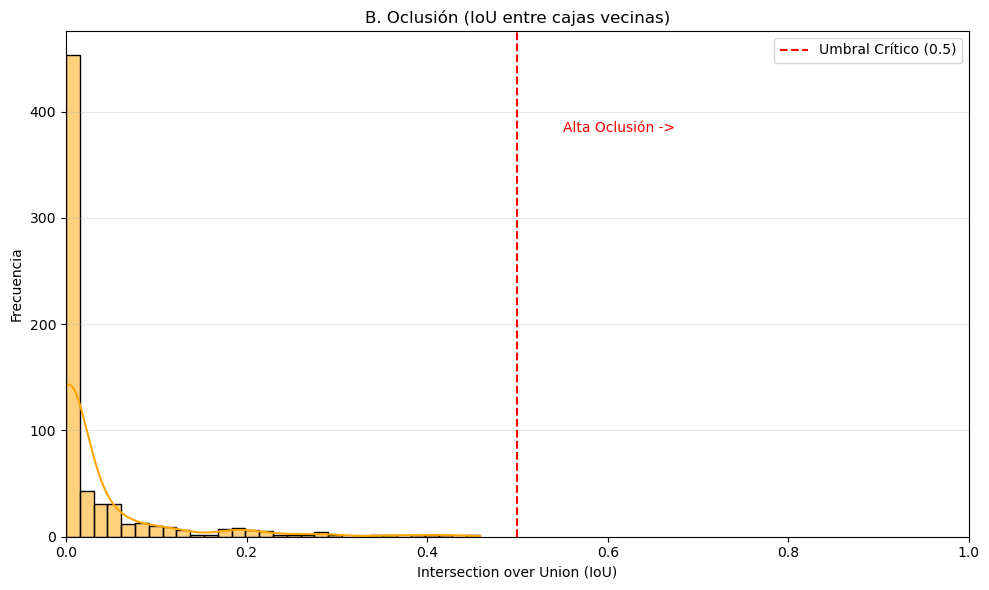

In [26]:
# Gráfico 2: Histograma de Oclusión (IoU)
plt.figure(figsize=(10, 6))
sns.histplot(ious, bins=30, color='orange', kde=True)
plt.title('B. Oclusión (IoU entre cajas vecinas)')
plt.xlabel('Intersection over Union (IoU)')
plt.ylabel('Frecuencia')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral Crítico (0.5)')
plt.text(0.55, plt.gca().get_ylim()[1]*0.8, 'Alta Oclusión ->', color='red', fontsize=10)
plt.xlim(0, max(1.0, max(ious) * 1.1))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Resumen numérico
print(f"Total Imágenes Analizadas: {len(img_ids)}")
print(f"Imágenes Vacías (Background): {density_counts.count(0)}")
print(f"Promedio de objetos por imagen: {np.mean(density_counts):.2f}")
print(f"Máximo de objetos en una imagen: {max(density_counts)}")

Total Imágenes Analizadas: 395
Imágenes Vacías (Background): 9
Promedio de objetos por imagen: 2.17
Máximo de objetos en una imagen: 12


**Análisis del Gráfico de Densidad de Escena (objetos por imagen):**

1. Se tiene solo 395 imágenes de entrenamiento, posiblemente un número bajo para Depp Learning; esto valida el uso de Transfer Learning de modelos pre-entrenados y aplicar Data Augmentation posibles (rotaciones, cambios de luz, mosaic) para que se aumente el número de imágenes efectivas.

2. Existen 9 imágenes vacías, que es bueno para que se le enseñe al modelo que no siempre hay objetos presentes. Sin embargo, es un número bajo (2.2% del dataset).  Lo ideal es que sea alrededor del 10%. El posible riesgo existente es que el modelo sea "paranoico" y vea obstáculos donde solo hay una pared vacía. Se podría considerar aumentar este número en futuras versiones del dataset.

3. Se tiene un máximo de 12 objetos por imagen, lo que parece ser manejable y son pocas las imágenes con tantos objetos. Esto es positivo pues indica que la mayoría de las imágenes tienen pocos objetos, lo que facilita el aprendizaje del modelo. Probablemente se pueda usar Batch Size de entre 16 a 32 imágenes sin que se bloquee la memoria GPU del PC de entrenamiento.



**Análisis del Gráfico de Oclusión (Overlapping Boxes):**

1. En general, se tiene una Oclusión Baja (IoU < 0.5) que simplifica el problema de detección. Implica que los objetos en el entorno de las imágenes están bien separados unos de otros. 

2. Lo anterior implica que el valor del NMS Threshold puede estar entre 0.45 y 0.5 , pues el gráfico muestra que en la "realidad" los objetos casi nunca se superponen más del 50%. Aunque en una futura aplicación práctica real, se tendría que considerar el contexto real del robot en particular, pues es probable que su entorno final sea diferente; por tanto, se requeriría enriquecer el dataset con imágenes del entorno real.

3. Con los valores de NMS Threshold entre 0.45 y 0.5, se esperaría que si los modelos predicen dos cajas con un IoU de 0.6, sabiendo que eso no ocurre en la realidad, podremos estar 99% seguros de que es un error (probablemente detectó el mismo objeto dos veces). 

4. El valor de NMS Threshold no debería ser menor de 0.2, porque se podrían borrar objetos válidos que estén simplemente cerca; el gráfico muestra que la mayoría están entre 0.1 y 0.2.

# Fase 4: Inspección Visual Cualitativa (Sanity Check)

Validación manual para asegurar la calidad de la información.

1.  **Visualización Randomizada:** Renderizar imágenes con sus etiquetas para confirmar la coherencia de las clases elegidas.
2.  **Verificación de "Ruido":** Identificar errores de etiquetado, como cajas que cubren toda la imagen o que son de tamaño minúsculo (1x1 píxel).

In [35]:
import cv2
import random
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN ---
# Definir colores para tus 4 clases (BGR para OpenCV)
class_colors = {
    'obstacle': (255, 0, 0),    # Rojo
    'person': (0, 255, 0),      # Verde
    'door': (0, 0, 255),        # Azul
    'footpath': (255, 255, 0)   # Cyan/Amarillo
}

# Directorio de imágenes
img_dir = os.path.dirname(train_annot_path)

def visualize_sample(num_samples=3, img_id=None):
    """
    Visualiza imágenes con sus anotaciones.
    
    Args:
        num_samples: Número de imágenes aleatorias a mostrar (si img_id=None)
        img_id: ID específico de imagen a mostrar (ignora num_samples si se especifica)
    """
    # Filtrar imágenes que contengan al menos una de nuestras clases objetivo
    target_img_ids = set()
    for cat_id in target_cat_ids:
        target_img_ids.update(coco.getImgIds(catIds=[cat_id]))
    
    target_img_ids = list(target_img_ids)
    
    # Determinar qué imágenes mostrar
    if img_id is not None:
        random_ids = [img_id]
        num_samples = 1
    else:
        random_ids = random.sample(target_img_ids, num_samples)
    
    plt.figure(figsize=(15, 5 * num_samples))
    
    for i, img_id in enumerate(random_ids):
        # Cargar info de imagen
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])
        
        # Leer imagen
        img = cv2.imread(img_path)
        if img is None:
            print(f"No se pudo cargar: {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Cargar anotaciones
        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=target_cat_ids)
        anns = coco.loadAnns(ann_ids)
        
        # Dibujar cajas
        for ann in anns:
            x, y, w, h = [int(v) for v in ann['bbox']]
            cat_name = id_to_name[ann['category_id']]
            color = class_colors.get(cat_name, (255, 255, 255))
            
            # Rectángulo
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            
            # Texto con fondo para legibilidad
            text_size, _ = cv2.getTextSize(cat_name, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img, (x, y - 20), (x + text_size[0], y), color, -1)
            cv2.putText(img, cat_name, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            
        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Imagen ID: {img_id} - {img_info['file_name']}")
        
    plt.tight_layout()
    plt.show()


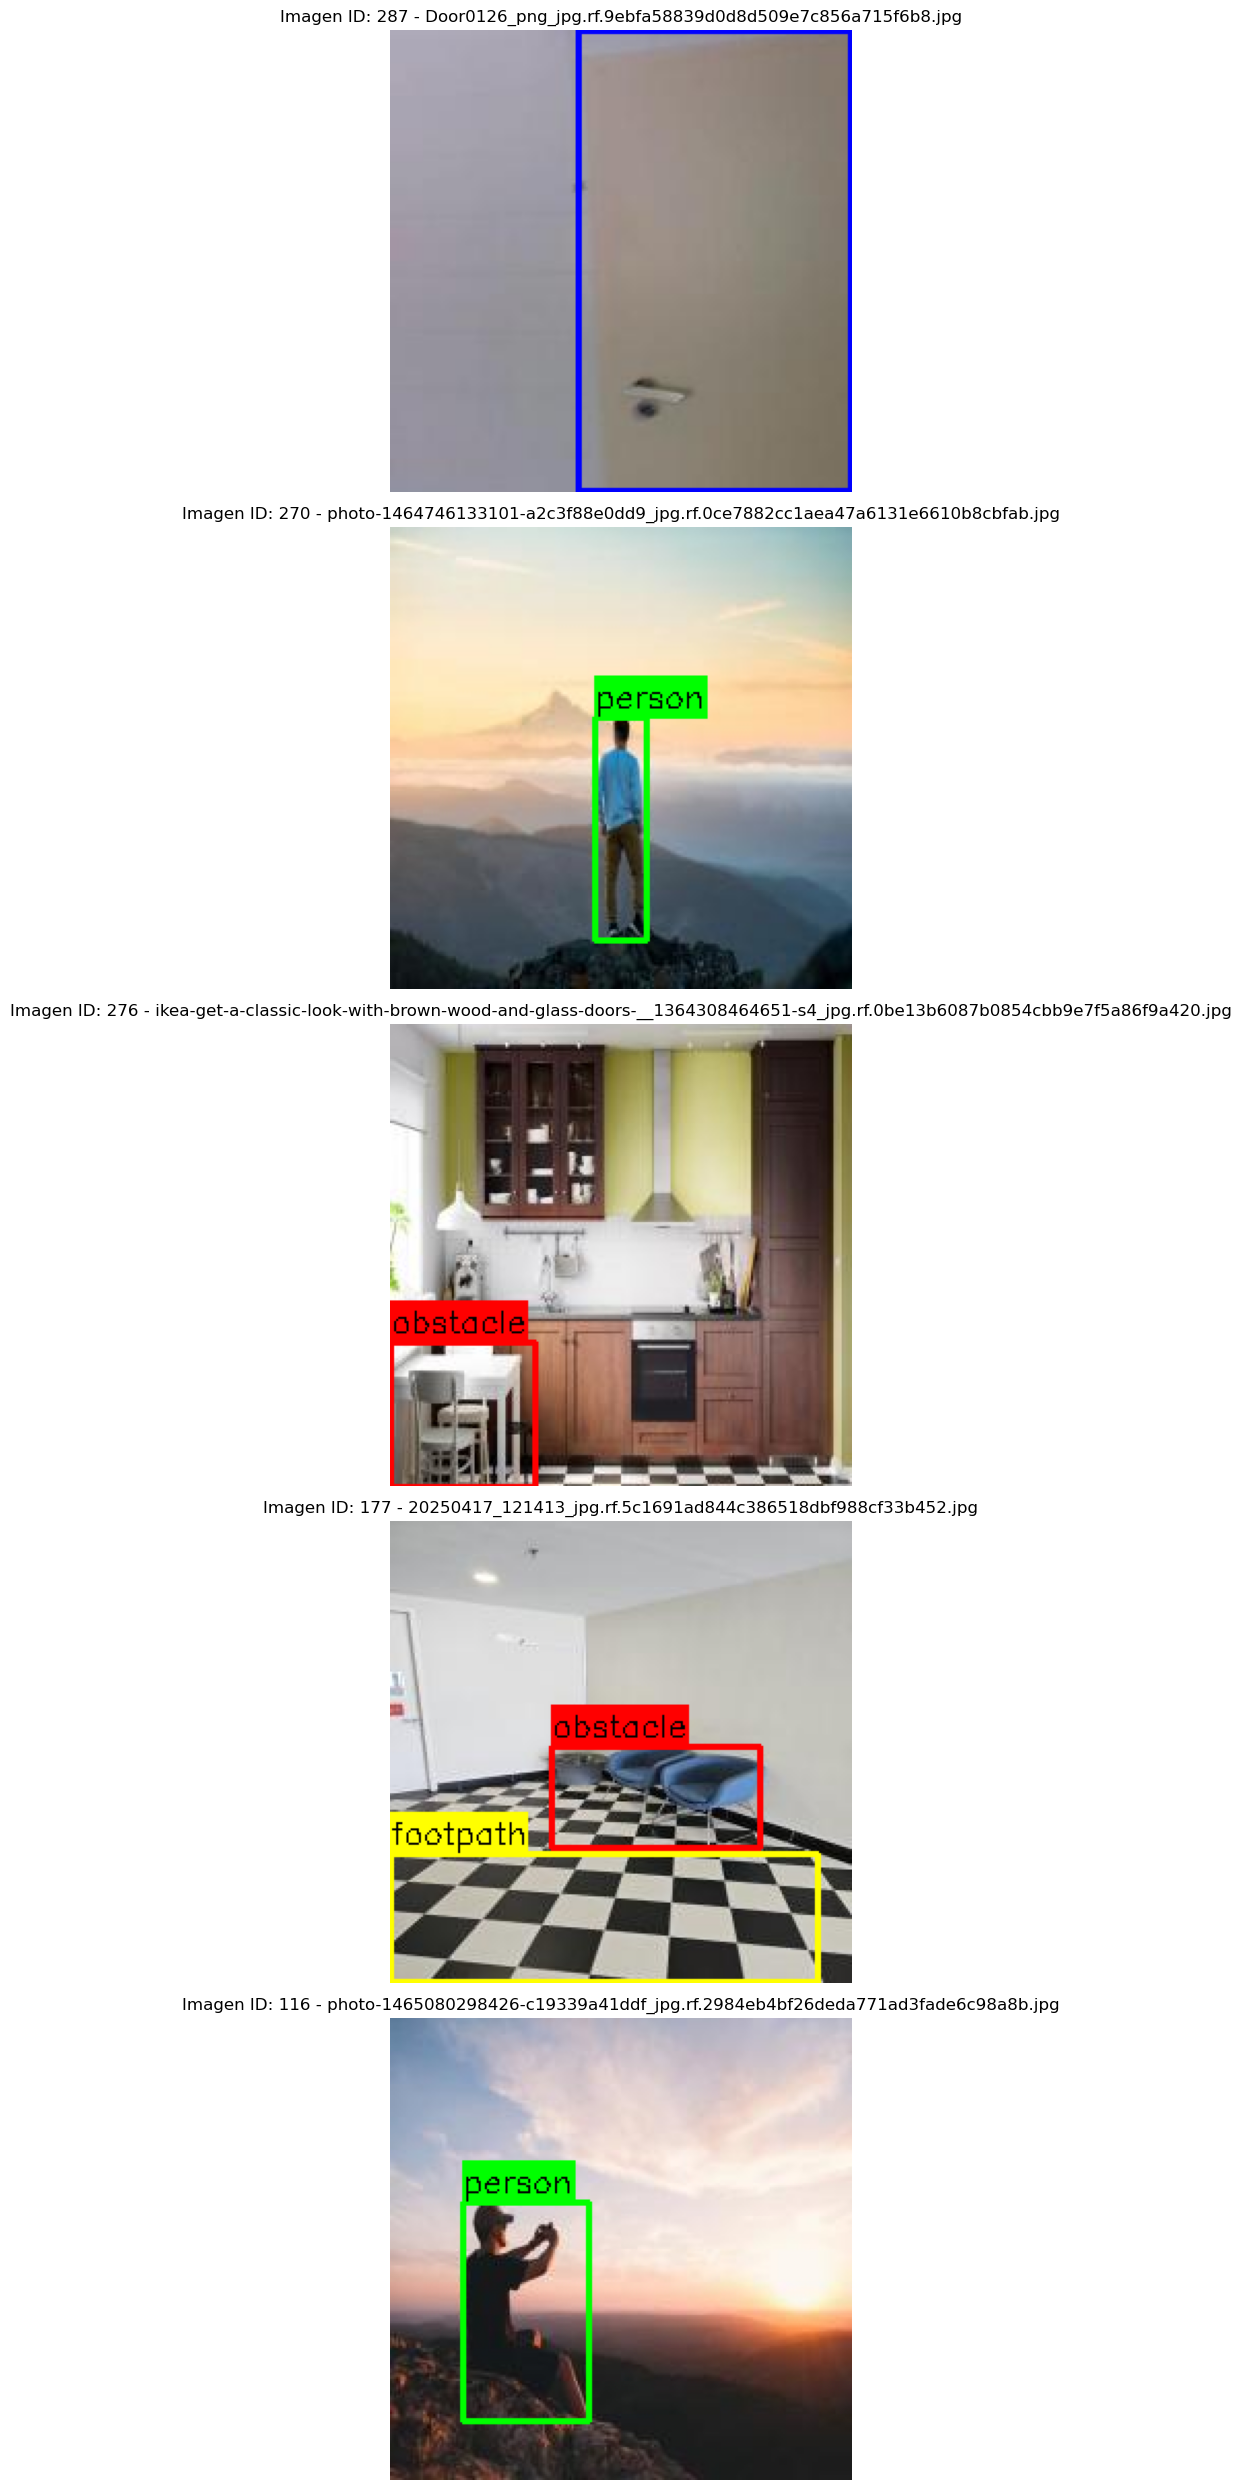

In [36]:
# Ejecutar visualización
visualize_sample(5)

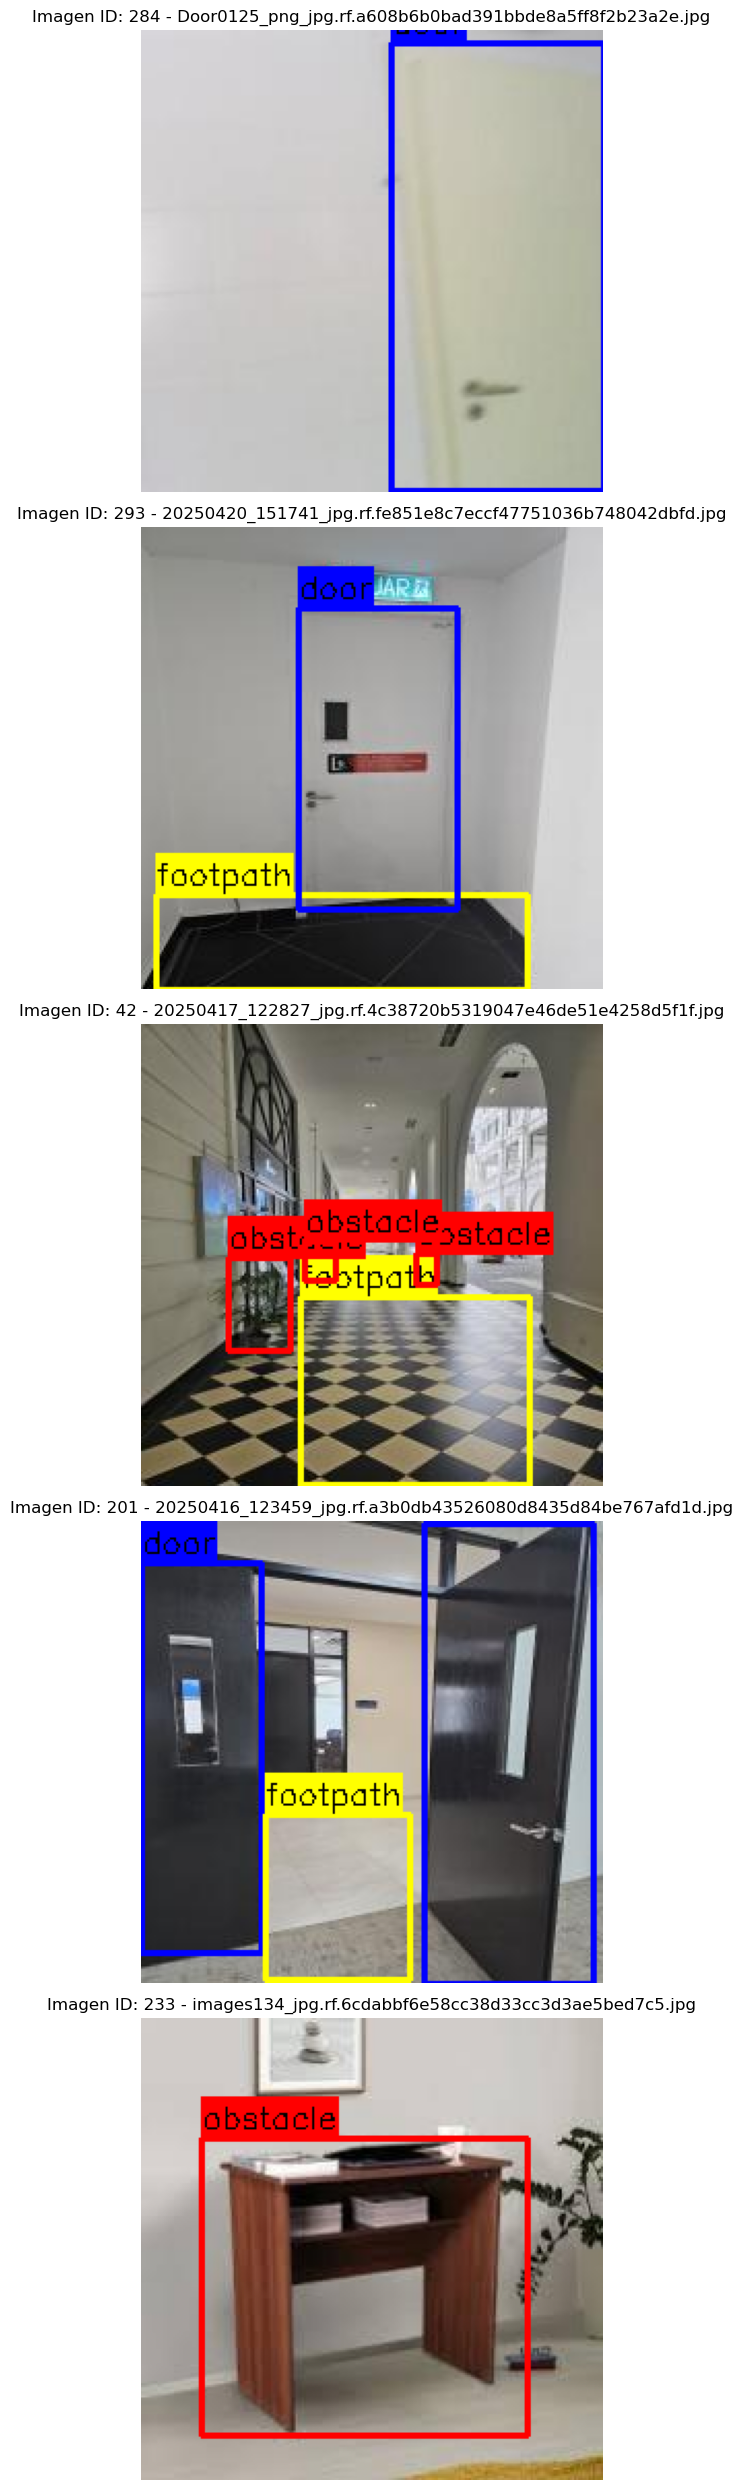

In [31]:
# Ejecutar visualización
visualize_sample(5)

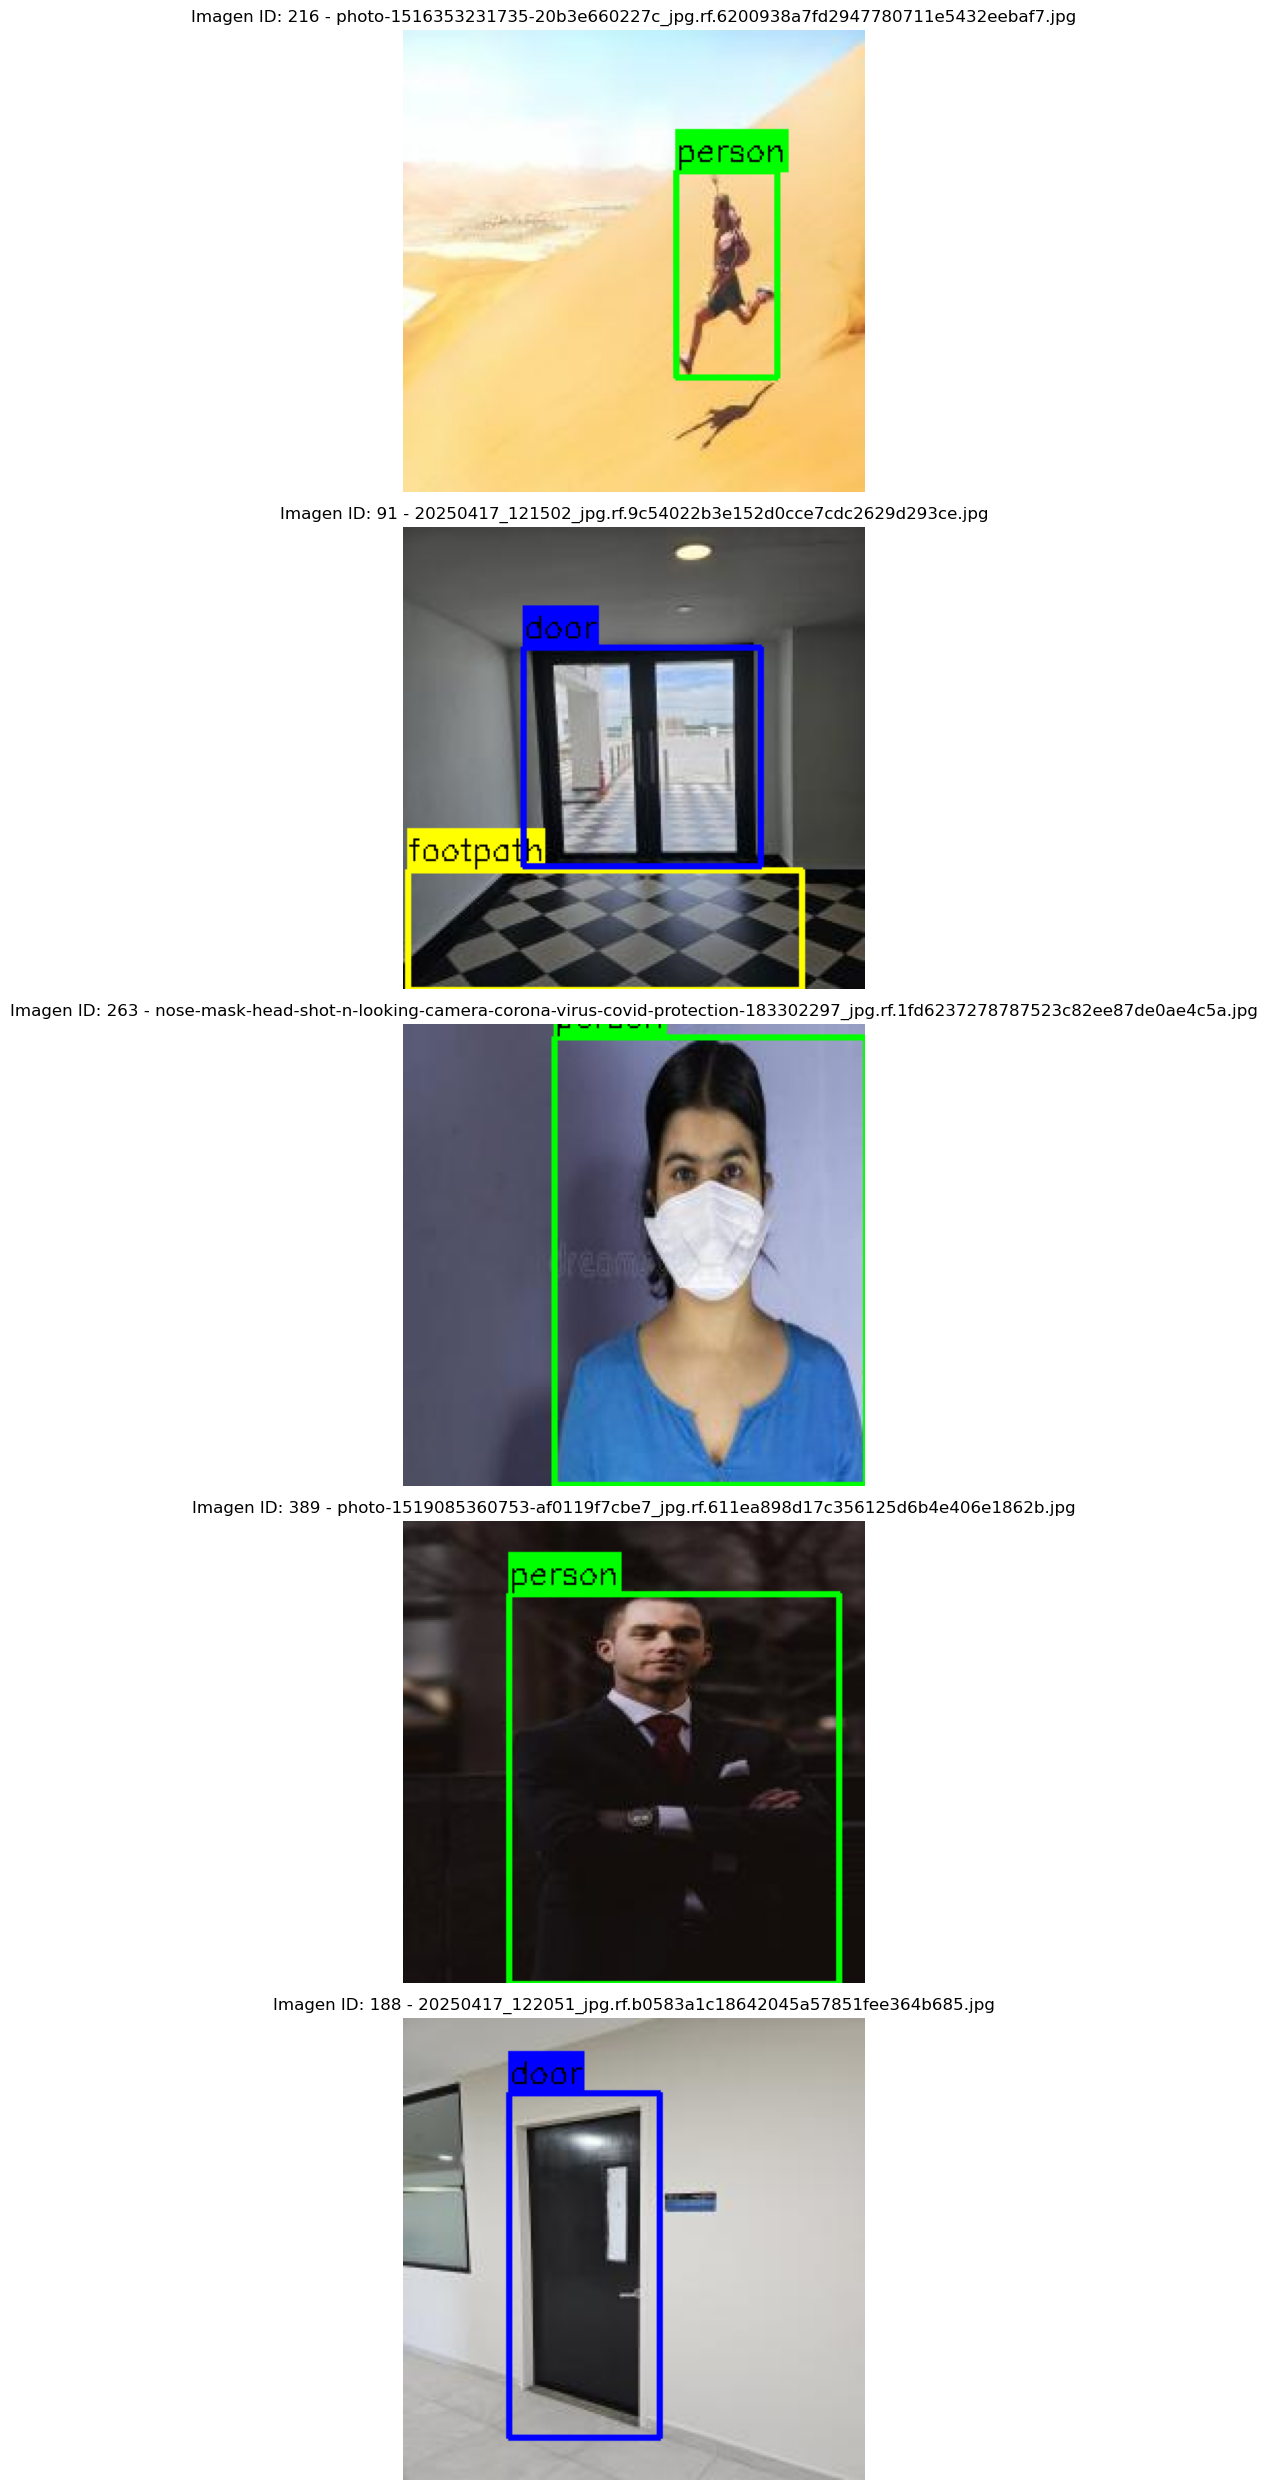

In [32]:
# Ejecutar visualización
visualize_sample(5)

**Análisis Visual de los Boxes:**
Después de hacer 3 sondeos:

1. Las cajas están bien etiquetadas, no se observan errores evidentes de etiquetado.
2. Las cajas cubren adecuadamente los objetos, sin incluir áreas irrelevantes.
3. No se observan cajas de tamaño inapropiado (muy pequeñas o muy grandes).

In [39]:
# --- DETECTOR DE ANOMALÍAS ---
print("--- Iniciando búsqueda de anomalías ---")

suspect_tiny = []
suspect_huge = []

for cat_id in target_cat_ids:
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    anns = coco.loadAnns(ann_ids)
    
    for ann in anns:
        x, y, w, h = ann['bbox']
        area = w * h
        
        # Obtener tamaño de imagen para comparar
        img_info = coco.loadImgs(ann['image_id'])[0]
        img_area = img_info['width'] * img_info['height']
        
        # CRITERIO 1: Cajas minúsculas (< 15x15 pixeles)
        # 1x1 es extremo, pero <225px ya es muy difícil de ver
        if area < 225: 
            suspect_tiny.append({
                'img_id': ann['image_id'],
                'category': id_to_name[cat_id],
                'bbox': [int(x), int(y), int(w), int(h)],
                'area': area
            })
            
        # CRITERIO 2: Cajas gigantes (> 95% de la imagen)
        if area > (img_area * 0.95):
            suspect_huge.append({
                'img_id': ann['image_id'],
                'category': id_to_name[cat_id],
                'bbox': [int(x), int(y), int(w), int(h)],
                'ratio': area/img_area
            })

print(f"\nResultados del escaneo:")
print(f"⚠️ Cajas Minúsculas (<15x15px): {len(suspect_tiny)}")
if len(suspect_tiny) > 0:
    print(pd.DataFrame(suspect_tiny).head(5).to_markdown())

print(f"\n⚠️ Cajas Gigantes (>95% imagen): {len(suspect_huge)}")
if len(suspect_huge) > 0:
    print(pd.DataFrame(suspect_huge).head(5).to_markdown())


--- Iniciando búsqueda de anomalías ---

Resultados del escaneo:
⚠️ Cajas Minúsculas (<15x15px): 40
|    |   img_id | category   | bbox               |   area |
|---:|---------:|:-----------|:-------------------|-------:|
|  0 |       16 | obstacle   | [106, 108, 7, 31]  |  220.5 |
|  1 |       31 | obstacle   | [91, 122, 10, 11]  |  115   |
|  2 |       36 | obstacle   | [137, 91, 12, 13]  |  162.5 |
|  3 |       42 | obstacle   | [133, 111, 10, 15] |  157.5 |
|  4 |       60 | obstacle   | [140, 105, 9, 11]  |  104.5 |

⚠️ Cajas Gigantes (>95% imagen): 4
|    |   img_id | category   | bbox             |    ratio |
|---:|---------:|:-----------|:-----------------|---------:|
|  0 |        5 | door       | [1, 1, 222, 222] | 0.982223 |
|  1 |       18 | door       | [0, 8, 223, 215] | 0.957759 |
|  2 |      391 | door       | [0, 0, 224, 224] | 1        |
|  3 |      131 | person     | [0, 9, 222, 215] | 0.951252 |



=== Visualizando ejemplos de CAJAS MINÚSCULAS ===


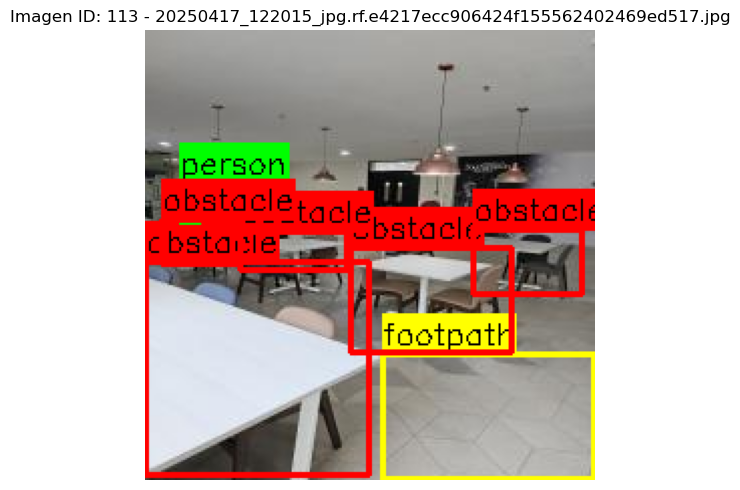

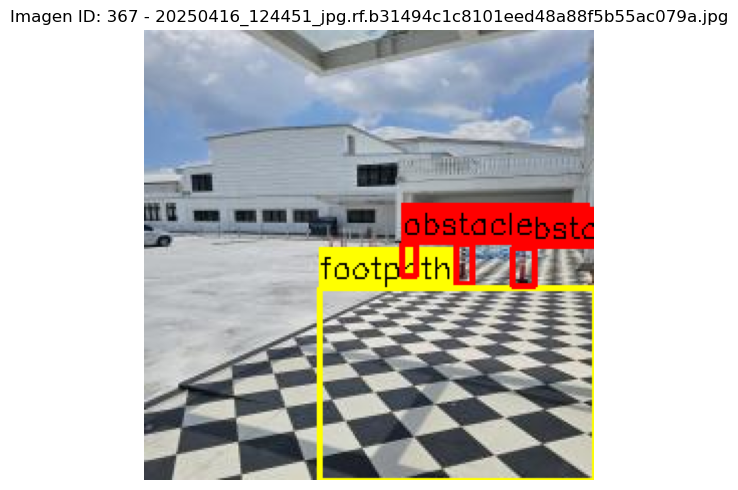

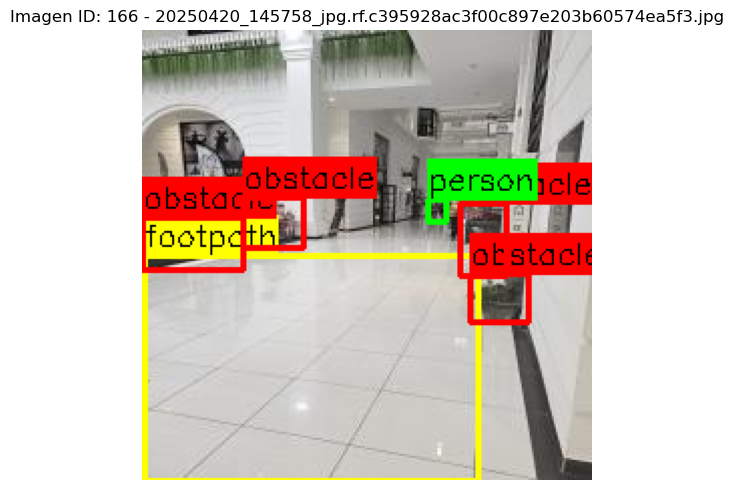

In [ ]:
# Visualizar imágenes de CAJAS MINÚSCULAS
if len(suspect_tiny) > 0:
    print("\n=== Visualizando ejemplos de CAJAS MINÚSCULAS ===")
    # Seleccionar hasta 3 ejemplos únicos (evitar repetir misma imagen)
    unique_tiny_ids = list(set([s['img_id'] for s in suspect_tiny]))
    sample_size = min(3, len(unique_tiny_ids))
    sample_tiny = random.sample(unique_tiny_ids, sample_size)
    
    for img_id in sample_tiny:
        visualize_sample(img_id=img_id)



=== Visualizando ejemplos de CAJAS GIGANTES ===


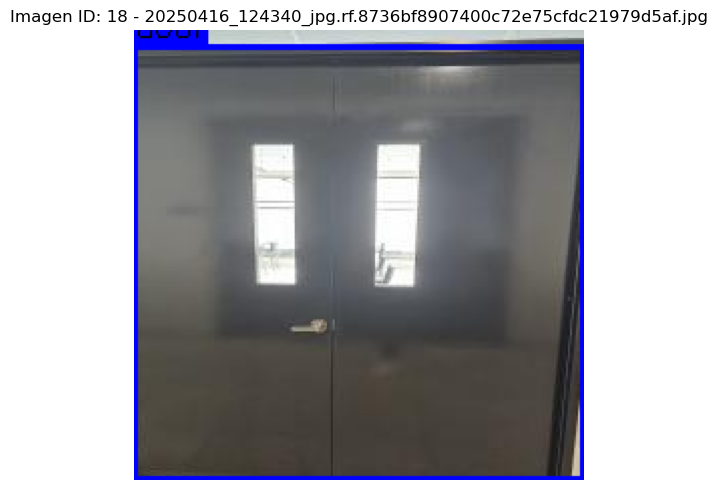

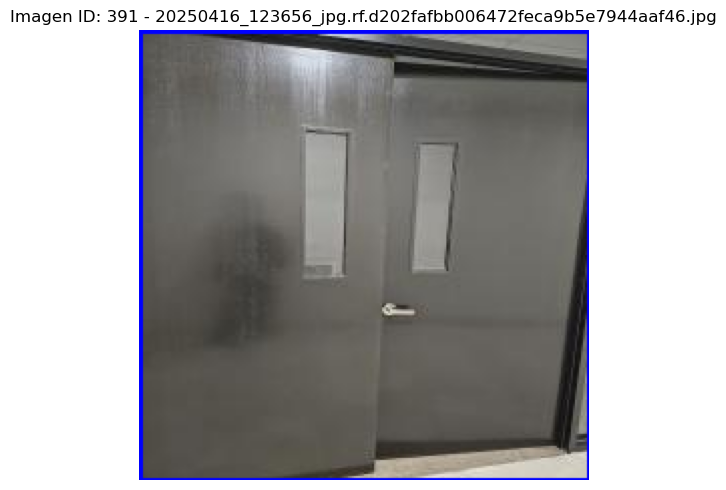

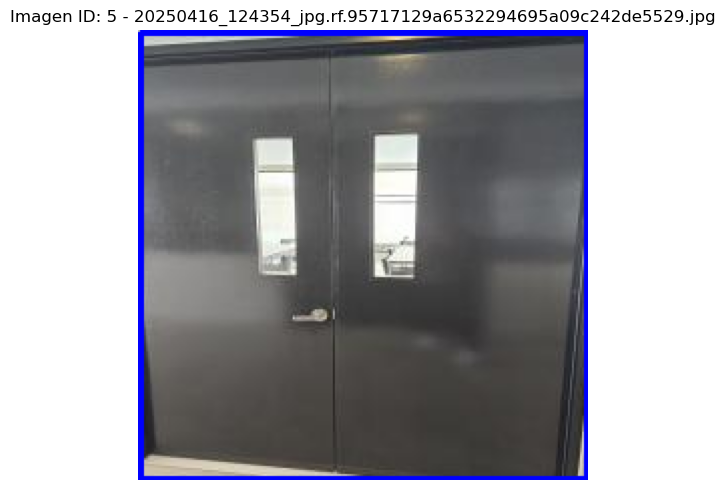

In [ ]:
# Visualizar imágenes de CAJAS GIGANTES
if len(suspect_huge) > 0:
    print("\n=== Visualizando ejemplos de CAJAS GIGANTES ===")
    # Seleccionar hasta 3 ejemplos únicos
    unique_huge_ids = list(set([s['img_id'] for s in suspect_huge]))
    sample_size = min(3, len(unique_huge_ids))
    sample_huge = random.sample(unique_huge_ids, sample_size)
    
    for img_id in sample_huge:
        visualize_sample(img_id=img_id)

**Análisis de la revisión de "ruido" en las etiquetas:**

1. Se toman en consideración como imágenes con cajas minúsculas a aquellas que tengan un área de 225 pixeles (< 15x15 pixeles). De estas se encontraron 40 imágenes. 

2. Se toman en consideración como imágenes con cajas gigantes a aquellas que tengan más del 95% del área de la imagen. De estas se encontraron 4 imágenes.

3. Se revisaron al azar 3 imágenes de cada grupo. En las imágenes con cajas minúsculas la mayor cantidad pertenecen a objetos de `obstacle` seguido de `person`. En las imágenes con cajas gigantes: 3 son de `door` y 1 de `person`.

4. La inspección visual de las imágenes con cajas minúsculas permite ver que se trata de objetos alejados de la cámara. Hay cajas de 7 pixeles de ancho ([106, 108, 7, 31]) y otras de 10x11 pixeles ([91, 122, 10, 11]). Un objeto de 10x10 pixeles es prácticamente un ruido en este contexto. Algunos modelos como YOLO estos ruidos podrían generar falsos positivos (detectar manchas en el piso como obstáculos). Llevándolo al entorno de aplicación en un robot móvil, si el obstáculo es tan pequeño (ej. una moneda o un papelito) probablemente el modelo lo detectará como obstáculo y no merezca la pena ejecutar acciones de control (detenerse, girar, etc.). Por lo tanto, se podría aplicar una limpieza de anotaciones o cajas que se consideran ruido, aquellas que tengan un área menor a 225 pixeles cuadrados para "sanear" las clases `obstacle` y `person`. Esto reduciría el total de instancias en 40, pero mejoraría la calidad del dataset.

5. La inspección visual de las imágenes con cajas gigantes muestra que son fotos de primer plano de las puertas y de una persona. Estas imágenes son más válidas para problemas de clasificación que de detección. Es probable que esto haga que el modelo aprenda a detectar paredes grandes y cercanas como puertas, aunque al ser tan baja la cantidad (4 imágenes) no debería afectar mucho el rendimiento general. Sin embargo, se podrían eliminar por seguridad.

6. También se pudo ver en los diferentes ejemplos de imágenes con cajas minúsculas y gigantes, que algunas cajas se superponen. Ejemplo: caja de `person` con caja de `obstacle` o entre la misma clase también. Esto quiere decir que los modelos deberán aprender que un pixel puede ser a la vez parte de dos objetos diferentes. Esto es un reto adicional para el modelo, pero es inevitable en escenarios reales donde los objetos se superponen. Por lo tanto, se debe aceptar esta limitación y esperar que el modelo aprenda a manejarla.



# Síntesis del EDA: Dataset Indoor Obstacle Detection

La siguiente tabla resume los hallazgos críticos del Análisis Exploratorio de Datos, sus implicaciones técnicas para un sistema de navegación robótica y las acciones correctivas definidas.

| Fase del EDA | Hallazgos Clave | Implicaciones Técnicas | Acción a realizar en Preprocesado | Acción a realizar en Entrenamiento |
| :--- | :--- | :--- | :--- | :--- |
| **1. Distribución y Categorías** | • Alta densidad en `obstacle` (>2 obj/img) y `person` (agrupados).<br>• Fuerte co-ocurrencia `footpath`-`obstacle` (40%).<br>• Solo 4 clases tienen volumen viable; el resto es ruido. | • El modelo debe manejar agrupamientos (clusters).<br>• Clases minoritarias causarán desbalance severo. | **Filtrar Dataset:** Mantener exclusivamente las clases `obstacle`, `person`, `door`, `footpath`. | NA |
| **2. Geometría (Tamaño y Forma)** | • `person`: 53% son pequeños (<32² px). Riesgo por downsampling.<br>• `obstacle`: Formas caóticas (anchas y altas) y 21% pequeños.<br>• Sesgo central fuerte en ubicación de objetos. | • Riesgo de no detectar personas lejanas.<br>• Anchors estándar fallarán con obstáculos anchos.<br>• Posible "visión de túnel" (no detectar en esquinas). | NA | • **Arquitectura:** Usar modelo con cabezales de detección pequeña (P5/P6).<br>• **Anchors:** Recalcular con K-Means (Autoanchor).<br>• **Augmentation:** Activar **Mosaic** obligatorio para mitigar sesgo central. |
| **3. Complejidad (Densidad y Oclusión)** | • Dataset pequeño (395 imgs) y pocas vacías (2.2%).<br>• Oclusión baja (IoU < 0.5) y densidad manejable (Max 12 obj/img). | • Riesgo de overfitting por escasez de datos.<br>• Facilidad para el algoritmo NMS separar objetos.<br>• Bajo consumo de VRAM. | NA | • **Transfer Learning:** Obligatorio (pesos COCO).<br>• **NMS:** Configurar `IoU Threshold` entre **0.45 y 0.50**.<br>• **Batch Size:** Configurar entre 16 y 32. |
| **4. Inspección Visual y Calidad** | • Ruido: 40 cajas minúsculas (<15x15 px), mayormente en `obstacle` (basura/manchas).<br>• Outliers: 4 cajas gigantes (>95% img) en `door`/`person` (problema de clasificación). | • Cajas minúsculas generan falsos positivos irrelevantes para navegación.<br>• Cajas gigantes confunden la localización espacial. | **Limpieza de Ruido:** Eliminar anotaciones con área < 225 px².<br>**Limpieza de Outliers:** Eliminar imágenes con cajas > 95% del área total. | NA (El modelo aprenderá a manejar superposiciones parciales intrínsecas). |